# Black–Litterman: how much conviction should become a portfolio tilt?

[Research note](README.md) · [Project overview](../../README.md)

We turn a reference allocation and two uncertain investment views into constrained portfolio weights. All inputs are **constructed**, expressed on one annual horizon, and fixed before the comparison. The view update raises emerging-equity and gold forecasts, while the confidence experiments expose how conditional that conclusion is. There is no backtest or empirical claim that these views predict returns.

## State the beliefs and their units

Let $\pi=\delta\Sigma w_0$ be reverse-optimized excess returns. The unknown expected-return vector has prior covariance $\tau\Sigma$. Views satisfy $Q=P\mu+\epsilon$, with view-error covariance $\Omega$ independent of the prior. The reference is an illustrative strategic allocation, not an estimate of market equilibrium. Both view-error standard deviations are errors about a mean forecast; they are not annual realized volatility.

The first view is **emerging equity minus global equity = 2.5 percentage points**. The second is **gold excess return = 3.5%**. Two rows of $P$ make the distinction between relative and absolute views inspectable.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / "research").is_dir():
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({"figure.figsize": (10, 4.2), "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
colors = ["#176b87", "#c45e28", "#6c578b", "#45836a"]
from research.views_tailrisk import black_litterman, quadratic_allocation

assets = ["Global equity", "Emerging equity", "Duration", "Gold"]
volatility = np.array([.17, .22, .08, .15])
correlation = np.array([[1, .75, -.1, .1], [.75, 1, -.1, .15],
                        [-.1, -.1, 1, .1], [.1, .15, .1, 1]])
covariance = np.outer(volatility, volatility) * correlation
reference = np.array([.45, .15, .30, .10])
delta, tau, cap = 3.0, .05, .60
picks = np.array([[-1, 1, 0, 0], [0, 0, 0, 1]])
views = np.array([.025, .035])
view_error_sd = np.array([.015, .025])
omega = np.diag(view_error_sd**2)
assert np.linalg.eigvalsh(covariance).min() > 0
view_table = pd.DataFrame(picks, columns=assets,
                          index=["Emerging minus global", "Gold absolute"])
view_table["View (% excess return)"] = 100 * views
view_table["View-error SD (pp)"] = 100 * view_error_sd
display(view_table)

,Global equity,Emerging equity,Duration,Gold,View (% excess return),View-error SD (pp)
Emerging minus global,-1,1,0,0,2.5,1.5
Gold absolute,0,0,0,1,3.5,2.5


## Separate forecast uncertainty from return risk

The Gaussian update is $\mu=\pi+\tau\Sigma P^\top(P\tau\Sigma P^\top+\Omega)^{-1}(Q-P\pi)$. Its covariance $M$ describes uncertainty about the mean. The covariance of a **future return** is $\Sigma+M$ if conditional return noise is independent of mean uncertainty. Using $M$ alone as the asset return covariance would omit that noise.

In [2]:
posterior = black_litterman(covariance, reference, delta, picks, views, omega, tau)
no_views = black_litterman(covariance, reference, delta, np.empty((0, 4)),
                           [], np.empty((0, 0)), tau)
forecast_table = pd.DataFrame({
    "Prior excess return (%)": 100 * posterior.implied_mean,
    "Posterior excess return (%)": 100 * posterior.posterior_mean,
    "Posterior mean SD (pp)": 100 * np.sqrt(np.diag(posterior.mean_covariance)),
    "Predictive return SD (%)": 100 * np.sqrt(np.diag(posterior.predictive_covariance)),
}, index=assets)
np.testing.assert_allclose(posterior.predictive_covariance,
                           covariance + posterior.mean_covariance)
display(forecast_table.round(2))

,Prior excess return (%),Posterior excess return (%),Posterior mean SD (pp),Predictive return SD (%)
Global equity,5.12,5.21,3.79,17.42
Emerging equity,5.95,7.45,4.00,22.36
Duration,0.35,0.39,1.78,8.20
Gold,1.35,2.78,2.00,15.13


## Make one constrained allocation decision

Maximize $w^\top\mu-\delta w^\top(\Sigma+M)w/2$, with weights summing to one and lying between zero and 60%. Including predictive mean uncertainty changes the no-view allocation relative to the reference. This is a covariance convention effect, not a hidden investment view.

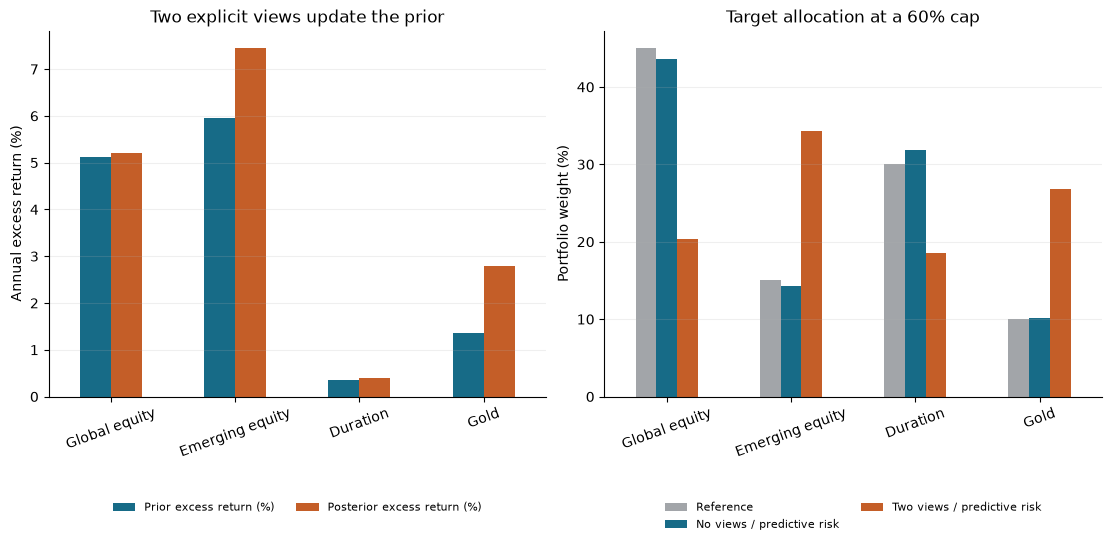

,Reference,No views / predictive risk,Two views / predictive risk
Global equity,45.0,43.7,20.3
Emerging equity,15.0,14.3,34.3
Duration,30.0,31.9,18.5
Gold,10.0,10.2,26.8


In [3]:
weights = {
    "Reference": reference,
    "No views / predictive risk": quadratic_allocation(
        no_views.posterior_mean, no_views.predictive_covariance, delta, cap),
    "Two views / predictive risk": quadratic_allocation(
        posterior.posterior_mean, posterior.predictive_covariance, delta, cap),
}
weight_table = pd.DataFrame(weights, index=assets)
np.testing.assert_allclose(weight_table.sum(), 1, atol=1e-8)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.3), constrained_layout=True)
forecast_table.iloc[:, :2].plot.bar(ax=axes[0], color=colors[:2], rot=20)
axes[0].set(title="Two explicit views update the prior", ylabel="Annual excess return (%)")
(weight_table * 100).plot.bar(ax=axes[1], color=["#a2a5a9", colors[0], colors[1]], rot=20)
axes[1].set(title="Target allocation at a 60% cap", ylabel="Portfolio weight (%)")
for ax in axes:
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=.2)
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(.5, -.26), ncol=2, frameon=False)
plt.show()
display((100 * weight_table).round(1))

The constructed views raise emerging equity's mean to about 7.45% and gold's to 2.78% excess return. Their resulting target weights are about 34.3% and 26.8%. The view is blended with its prior, so gold does not simply receive its asserted 3.5% forecast. The surrounding covariance structure also updates exposures absent from $P$.

## Retain the confidence and prior sensitivity

First vary the **standard deviation** of both view errors together; multiplying that standard deviation by two multiplies $\Omega$ by four. Then vary $\tau$ while holding $\Omega$ fixed. Every setting is retained. Neither plot is an optimization over future portfolio outcomes.

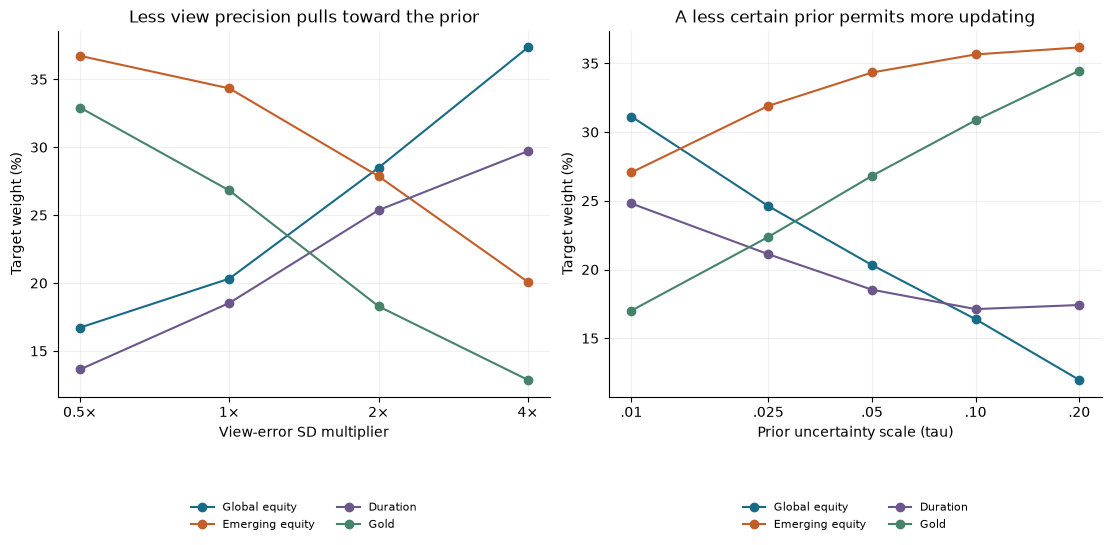

In [4]:
error_multipliers = np.array([.5, 1, 2, 4])
prior_scales = np.array([.01, .025, .05, .10, .20])

def updated_weights(prior_scale, error_multiplier):
    update = black_litterman(covariance, reference, delta, picks, views,
                             omega * error_multiplier**2, prior_scale)
    return quadratic_allocation(update.posterior_mean, update.predictive_covariance, delta, cap)

confidence_weights = np.array([updated_weights(tau, k) for k in error_multipliers])
prior_weights = np.array([updated_weights(k, 1) for k in prior_scales])
fig, axes = plt.subplots(1, 2, figsize=(11, 5.3), constrained_layout=True)
for j, asset in enumerate(assets):
    axes[0].plot(error_multipliers, 100 * confidence_weights[:, j], "o-", color=colors[j], label=asset)
    axes[1].plot(prior_scales, 100 * prior_weights[:, j], "o-", color=colors[j], label=asset)
axes[0].set(title="Less view precision pulls toward the prior", xlabel="View-error SD multiplier",
            ylabel="Target weight (%)", xscale="log", xticks=error_multipliers)
axes[0].set_xticklabels(["0.5×", "1×", "2×", "4×"])
axes[1].set(title="A less certain prior permits more updating", xlabel="Prior uncertainty scale (tau)",
            ylabel="Target weight (%)", xscale="log", xticks=prior_scales)
axes[1].set_xticklabels([".01", ".025", ".05", ".10", ".20"])
for ax in axes:
    ax.minorticks_off()
    ax.grid(alpha=.2)
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(.5, -.26), ncol=2, frameon=False)
plt.show()

The confidence plot shifts gold and emerging-equity exposure as belief precision changes. These curves are sensitivity evidence, not proof that more confidence improves investment results. Changing $\tau$ also changes predictive risk, so the second panel includes both an updating effect and a risk-objective effect.

## Check the algebra independently

The precision-form update should equal the gain-form implementation. A scalar update can be checked by elementary precision weighting. A view equal to its prior prediction leaves the posterior mean unchanged but still reduces uncertainty. With no views, uncertainty remains $\tau\Sigma$. Finally, when $\Omega$ is proportional to $\tau$, that common scale cancels from the posterior **mean**, but not from $M$.

In [5]:
prior_precision = np.linalg.inv(tau * covariance)
precision = prior_precision + picks.T @ np.linalg.solve(omega, picks)
reference_mean = np.linalg.solve(
    precision, prior_precision @ posterior.implied_mean + picks.T @ np.linalg.solve(omega, views))
np.testing.assert_allclose(reference_mean, posterior.posterior_mean)
np.testing.assert_allclose(np.linalg.inv(precision), posterior.mean_covariance)
scalar = black_litterman([[.04]], [1], 2, [[1]], [.12], [[.003]], tau=.1)
np.testing.assert_allclose(scalar.posterior_mean, [( .08/.004 + .12/.003 ) / (1/.004 + 1/.003)])
no_innovation = black_litterman(covariance, reference, delta, picks,
                                picks @ posterior.implied_mean, omega, tau)
np.testing.assert_allclose(no_innovation.posterior_mean, posterior.implied_mean)
assert np.trace(no_innovation.mean_covariance) < np.trace(tau * covariance)
np.testing.assert_allclose(no_views.mean_covariance, tau * covariance)
np.testing.assert_allclose(np.linalg.solve(delta * covariance, posterior.implied_mean), reference)
# SLSQP objective tolerance implies sub-micro-weight numerical error here.
np.testing.assert_allclose(quadratic_allocation(posterior.implied_mean, covariance, delta),
                           reference, atol=1e-6)
scaled = black_litterman(covariance, reference, delta, picks, views, omega * 4, tau * 4)
np.testing.assert_allclose(scaled.posterior_mean, posterior.posterior_mean)
np.testing.assert_allclose(scaled.mean_covariance, 4 * posterior.mean_covariance)
print("Passed precision-form, scalar, no-innovation, no-view, reverse-optimization and scale identities.")

Passed precision-form, scalar, no-innovation, no-view, reverse-optimization and scale identities.


## What to carry into a strategy study

The rule must specify the reference portfolio, information used to generate each view, covariance estimator, confidence mapping, rebalance dates and costs **before** next-period evaluation. Manually tuning views or $\Omega$ to a successful backtest adds a model-selection problem; Bayesian shrinkage does not erase it. These annual target allocations do not establish realized turnover, returns or dominance over equal weighting. Compare with [estimation-risk diagnostics](../12-estimation-risk/README.md) and [validation design](../10-purged-validation/README.md).

Sources: [Black and Litterman (1992)](https://people.duke.edu/~charvey/Teaching/BA453_2005/blacklitterman.pdf), and [the official PyPortfolioOpt formula documentation](https://pyportfolioopt.readthedocs.io/en/latest/BlackLitterman.html). All exposure inputs, sensitivity experiments and figures here are original constructed examples. We implement the equations directly; no external portfolio package supplies the numerical answers.